In [1]:
import xarray as xr
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, r2_score
import torch
from torch.utils.data import TensorDataset, DataLoader
from skimage.metrics import structural_similarity as ssim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.colors import CenteredNorm
from sklearn.metrics import classification_report, jaccard_score, cohen_kappa_score, confusion_matrix
import seaborn as sns

from io import BytesIO
from openpyxl.drawing.image import Image

In [2]:
target_res = 0.125
min_lon, min_lat, max_lon, max_lat =[-61.0, -47.5, -60.0, -44.875]

min_time, max_time = pd.to_datetime("2013-01-01"), pd.to_datetime("2025-12-31")
sp = "HKP"
fishing_ds = xr.open_dataset(f"../data/processed/targets/cpue_{target_res}.nc").sel(FAOspp=sp)
fishing = fishing_ds["CPUE_class"]
fishing = fishing.fillna(0)

effort = xr.open_dataset(f"../data/processed/targets/esfuerzo_{target_res}.nc")
effort = effort["Horas"]/24
effort = effort.fillna(0)

mask_ds = xr.open_dataset(f"../data/processed/static/area_pesca_{target_res}.nc")
mask = mask_ds["mask"]
mask = mask.fillna(0)
mask = mask.broadcast_like(fishing)

temp_ds = xr.open_dataset("../data/processed/dynamic/to_surface.nc")
temp = temp_ds["to"]
temp = (temp - temp.mean()) / temp.std()
temp = temp.fillna(0)

temp_bottom_ds = xr.open_dataset("../data/processed/dynamic/temp_bottom.nc")
temp_bottom_ds = temp_bottom_ds.rename({"to": "to_b"})
temp_bottom = temp_bottom_ds["to_b"]
temp_bottom = (temp_bottom - temp_bottom.mean()) / temp_bottom.std()
temp_bottom = temp_bottom.fillna(0)

chl_ds = xr.open_dataset("../data/processed/dynamic/chl.nc")
chl = chl_ds["CHL"]
chl = (chl - chl.mean()) / chl.std()
chl = chl.fillna(0)

mixed_ds = xr.open_dataset("../data/processed/dynamic/mixed_layer.nc")
mixed = mixed_ds["mlotst"]
mixed = (mixed - mixed.mean()) / mixed.std()
mixed = mixed.fillna(0)

depth_ds = xr.open_dataset("../data/processed/static/depth.nc")
depth = depth_ds["depth"] 
depth = (depth - depth.mean()) / depth.std()
depth = depth.fillna(0)
depth = depth.broadcast_like(temp)

zo_ds = xr.open_dataset("../data/processed/dynamic/zo_surface.nc")
zo = zo_ds["zo"]
zo = (zo - zo.mean()) / zo.std()
zo = zo.fillna(0)

so_ds = xr.open_dataset("../data/processed/dynamic/so_surface.nc")
so = so_ds["so"]
so = (so - so.mean()) / so.std()
so = so.fillna(0)

ugo_ds = xr.open_dataset("../data/processed/dynamic/ugo_surface.nc")
ugo = ugo_ds["ugo"]
ugo = (ugo - ugo.mean()) / ugo.std()
ugo = ugo.fillna(0)

vgo_ds = xr.open_dataset("../data/processed/dynamic/vgo_surface.nc")
vgo = vgo_ds["vgo"]
vgo = (vgo - vgo.mean()) / vgo.std()
vgo = vgo.fillna(0)

pp = xr.open_dataset("../data/processed/dynamic/pp.nc")
pp = pp["PP"]
pp = (pp - pp.mean()) / pp.std()
pp = pp.fillna(0)

cdm = xr.open_dataset("../data/processed/dynamic/cdm.nc")
cdm = cdm["CDM"]
cdm = (cdm - cdm.mean()) / cdm.std()
cdm = cdm.fillna(0)

spm = xr.open_dataset("../data/processed/dynamic/spm.nc")
spm = spm["SPM"]
spm = (spm - spm.mean()) / spm.std()    
spm = spm.fillna(0)

zsd = xr.open_dataset("../data/processed/dynamic/zsd.nc")
zsd = zsd["ZSD"]
zsd = (zsd - zsd.mean()) / zsd.std()
zsd = zsd.fillna(0)


month = temp["time"].dt.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)
month_sin = month_sin.broadcast_like(temp)
month_cos = month_cos.broadcast_like(temp)
month = month.broadcast_like(temp)

year = temp["time"].dt.year
year = (year - year.mean()) / year.std()
year = year.broadcast_like(temp)

lat = (temp["lat"] - temp["lat"].mean()) / temp["lat"].std()
lon = (temp["lon"] - temp["lon"].mean()) / temp["lon"].std()
lat = lat.broadcast_like(temp)
lon = lon.broadcast_like(temp)

temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, ugo, vgo, pp, cdm, spm, zsd = xr.align(
    temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, vgo, ugo, pp, cdm, spm, zsd, join="inner")

fishing, effort, mask = xr.align(fishing, effort, mask, join="inner")


#area de pesca y un poco alrededor
croppedT = lambda da: da.sel(
    lon=slice(min_lon-0.5, max_lon+0.5),
    lat=slice(min_lat-0.5, max_lat+0.5),
    time=slice(min_time, max_time)
)

# area global
cropped = lambda da: da.sel(
    lon=slice(min_lon-0, max_lon+2),
    lat=slice(min_lat-4, max_lat+1),
    time=slice(min_time, max_time)
)

fishing = croppedT(fishing)
effortT = croppedT(effort)    
mask = croppedT(mask)

effortV = cropped(effort)
temp = cropped(temp)
temp_bottom = cropped(temp_bottom)
chl = cropped(chl)
mixed = cropped(mixed)
depth = cropped(depth)
zo = cropped(zo)
so = cropped(so)
month = cropped(month)
month_sin = cropped(month_sin)
month_cos = cropped(month_cos)
lat = cropped(lat)
lon = cropped(lon)
year = cropped(year)
ugo = cropped(ugo)
vgo = cropped(vgo)
pp = cropped(pp)
cdm = cropped(cdm)
spm = cropped(spm)
zsd = cropped(zsd)

In [3]:
y = fishing
y = y.transpose("time", "lat", "lon")

m = mask 
m = m.transpose("time", "lat", "lon")


vars_ = [temp, so, mixed, zo, temp_bottom,  
        ugo, vgo, chl, cdm, pp,
        month_sin, month_cos,
        # lat, lon,
        # depth,
        ]

vars_names = [v.name for v in vars_]
in_channels = len(vars_)
X = xr.concat(vars_, dim="channel")
X = X.transpose("time", "channel", "lat", "lon")
print(X.shape)
print(y.shape)
print(m.shape)

split_year = 2022

train_X = X.sel(time=slice(None, f"{split_year-1}-12-31"))
test_X  = X.sel(time=slice(f"{split_year}-01-01", None))

train_y = y.sel(time=slice(None, f"{split_year-1}-12-31"))
test_y  = y.sel(time=slice(f"{split_year}-01-01", None))

m_train = m.sel(time=slice(None, f"{split_year-1}-12-31"))
m_test  = m.sel(time=slice(f"{split_year}-01-01", None))


# -------- Check inflation factor --------
X_np = train_X.values  # (time, channel, lat, lon)
t, c, h, w = X_np.shape
X_flat = X_np.reshape(t, c, -1)       # (time, channel, pixels)
X_flat = X_flat.transpose(0, 2, 1)    # (time, pixels, channel)
X_flat = X_flat.reshape(-1, c)        # (samples, channel)
df = pd.DataFrame(X_flat, columns=vars_names)
vif_data = pd.DataFrame()
vif_data["feature"] = df.columns
vif_data["VIF"] = [variance_inflation_factor(df.values, i)for i in range(df.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))

def create_windows(X, y, m, window=12):
    X_data = X.values   # (time, channels, H, W)
    y_data = y.values   # (time, H, W)
    m_data = m.values   # (time, H, W)

    X_seq, y_seq, m_seq= [], [], []

    for i in range(len(X_data) - window):
        X_seq.append(X_data[i:i+window]) #12 months
        y_seq.append(y_data[i+window]) #next month
        m_seq.append(m_data[i+window]) #next month
        

    return (
        torch.tensor(np.stack(X_seq), dtype=torch.float32),
        torch.tensor(np.stack(y_seq), dtype=torch.float32),
        torch.tensor(np.stack(m_seq), dtype=torch.float32),
    )

window = 12 #12 months

X_train, y_train, m_train = create_windows(train_X, train_y, m_train, window)
X_test, y_test, m_test = create_windows(test_X, test_y, m_test, window)

print(X_train.shape)  # (N, T, C, H, W)
print(y_train.shape)  # (N, H, W)
print(m_train.shape)  # (N, H, W)
###### Data Loaders ######
batch_size = 24

train_loader = DataLoader(
    TensorDataset(X_train, y_train, m_train),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test, m_test),
    batch_size=batch_size,
    shuffle=False
)


(156, 12, 62, 25)
(156, 30, 17)
(156, 30, 17)
   feature        VIF
9       PP  10.012981
7      CHL   7.659927
0       to   6.277826
4     to_b   6.048060
3       zo   5.104078
1       so   4.480894
10   month   3.984513
11   month   3.385814
5      vgo   2.920806
2   mlotst   2.735247
8      CDM   2.345182
6      ugo   2.264724
torch.Size([96, 12, 12, 62, 25])
torch.Size([96, 30, 17])
torch.Size([96, 30, 17])


In [4]:
def prep_ml_data(X, y, m=None):
    """
    Converts 5D input tensors and 3D target tensors into 2D arrays 
    compatible with scikit-learn Random Forest. Handles both Torch tensors and Numpy arrays.
    """
    # Move to CPU and convert to numpy if dealing with PyTorch Tensors
    if isinstance(X, torch.Tensor):
        X = X.detach().cpu().numpy()
    if isinstance(y, torch.Tensor):
        y = y.detach().cpu().numpy()
    if isinstance(m, torch.Tensor):
        m = m.detach().cpu().numpy()

    N = X.shape[0]
    
    # Flatten features: (N, T, C, H_x, W_x) -> (N, T * C * H_x * W_x)
    # For your train data: (72, 12, 11, 94, 48) -> (72, 595584)
    X_rf = X.reshape(N, -1)
    
    # Flatten targets: (N, H_y, W_y) -> (N, H_y * W_y)
    # For your train data: (72, 37, 20) -> (72, 740)
    y_rf = y.reshape(N, -1)
    
    if m is not None:
        m_rf = m.reshape(N, -1)
        return X_rf, y_rf, m_rf
    else:
        return X_rf, y_rf

X_train_ml, y_train_ml, m_train_ml = prep_ml_data(X_train, y_train, m_train)
X_test_ml, y_test_ml, m_test_ml = prep_ml_data(X_test, y_test, m_test)

H_out_test, W_out_test = y_test.shape[1], y_test.shape[2]

m_true = m_test_ml.reshape(-1, H_out_test, W_out_test)
y_true = y_test_ml.reshape(-1, H_out_test, W_out_test)

mask_flat = m_test_ml.astype(bool)

In [ ]:
def compute_metrics(y_test_ml, y_pred_flat, y_true, mask_spatial):

    # =====================================================
    # 1. FLATTEN FOR METRICS
    # =====================================================
    y_test_flat = y_test_ml.flatten()
    y_pred_flat = y_pred_flat.flatten()
    
    mask_spatial = mask_spatial.astype(bool)
    mask_flat = mask_spatial.flatten().astype(bool)
    

    y_test_masked = y_test_flat[mask_flat]
    y_pred_masked = y_pred_flat[mask_flat]
    # =====================================================
    # 2. Classification Metrics
    # =====================================================
    print("=== Classification Report ===")
    report = pd.DataFrame(classification_report(y_test_masked, y_pred_masked, labels=[0, 1, 2], output_dict=True)).T
    print(report)
    
    iou_per_class = jaccard_score(y_test_masked, y_pred_masked, average=None, labels=[0, 1, 2])
    kappa = cohen_kappa_score(y_test_masked, y_pred_masked)
    
    print("=== Spatial Segmentation Metrics ===")
    print(f"IoU Class 1 (Low CPUE):      {iou_per_class[1]:.3f}")
    print(f"IoU Class 2 (High CPUE):     {iou_per_class[2]:.3f}")
    print(f"Cohen's Kappa Score:         {kappa:.3f}\n")
    
    # New Plot: Confusion Matrix
    class_labels = ['Nada (0)', 'CPUE bajo (1)', 'CPUE alto (2)']
    cm = pd.DataFrame(confusion_matrix(y_test_masked, y_pred_masked, labels=[0, 1, 2]), index=class_labels, columns=class_labels)
    
    # =====================================================
    # SSIM
    # =====================================================
    H_out, W_out = y_true.shape[1], y_true.shape[2]
    y_pred3D = y_pred_flat.reshape(-1, H_out, W_out)
    mask_spatial = mask_spatial.astype(bool)

    data_range = (y_true[mask_spatial].max()-y_true[mask_spatial].min())

    ssim_scores = []

    for i in range(y_true.shape[0]):

        _, ssim_map = ssim(
            y_true[i],
            y_pred3D[i],
            data_range=data_range,
            win_size=5,
            full=True
        )

        valid_ssim_pixels = ssim_map[mask_spatial[i]]

        if len(valid_ssim_pixels) > 0:
            ssim_scores.append(np.mean(valid_ssim_pixels))

    mean_ssim = np.mean(ssim_scores)

    print(f"Mean Masked SSIM: {mean_ssim:.4f}\n")

    # =====================================================
    # PLOTTING
    # =====================================================
    y_pred_mean = np.mean(y_pred3D, axis=0)
    y_true_mean = np.mean(y_true, axis=0)

    error = y_pred_mean - y_true_mean

    plt.figure(figsize=(12, 4))

    ax1 = plt.subplot(1, 3, 1)
    plt.title("Mean Test Truth")
    plt.imshow(y_true_mean, cmap='viridis')
    plt.colorbar()
    ax1.invert_yaxis()

    ax2 = plt.subplot(1, 3, 2)
    plt.title("Mean Test Prediction")
    plt.imshow(y_pred_mean, cmap='viridis')
    plt.colorbar()
    ax2.invert_yaxis()

    ax3 = plt.subplot(1, 3, 3)
    plt.title("Mean Error (Pred - True)")
    plt.imshow(error, cmap='coolwarm', norm=CenteredNorm())
    plt.colorbar()
    ax3.invert_yaxis()

    plt.tight_layout()
    plt.show()

    y_pred_plot2 = np.sum(y_pred3D, axis=(1, 2))
    y_true_plot2 = np.sum(y_true, axis=(1, 2))
    r2_plot2 = r2_score(y_true_plot2, y_pred_plot2)

    return report, iou_per_class, kappa, cm, y_true_plot2, y_pred_plot2, r2_plot2


=== Classification Report ===
              precision    recall  f1-score      support
0              0.764706  0.892473  0.823664  2418.000000
1              0.546875  0.358056  0.432767  1173.000000
2              0.560440  0.561056  0.560748   909.000000
accuracy       0.686222  0.686222  0.686222     0.686222
macro avg      0.624007  0.603862  0.605726  4500.000000
weighted avg   0.666663  0.686222  0.668661  4500.000000
=== Spatial Segmentation Metrics ===
IoU Class 1 (Low CPUE):      0.276
IoU Class 2 (High CPUE):     0.390
Cohen's Kappa Score:         0.457

Mean Masked SSIM: 0.4478



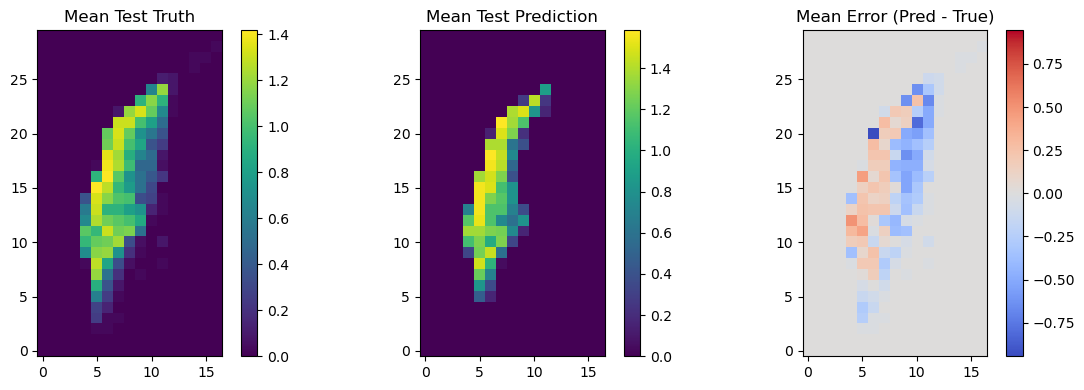

   Variable  Importance
0        to    0.144775
1        PP    0.110438
2    mlotst    0.107229
3       CHL    0.095803
4       vgo    0.087626
5       ugo    0.083737
6      to_b    0.082379
7       CDM    0.081264
8        so    0.079741
9        zo    0.076996
10    month    0.026890
11    month    0.023121


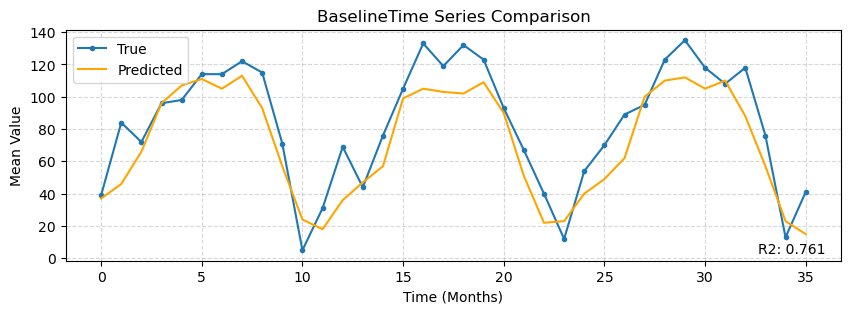

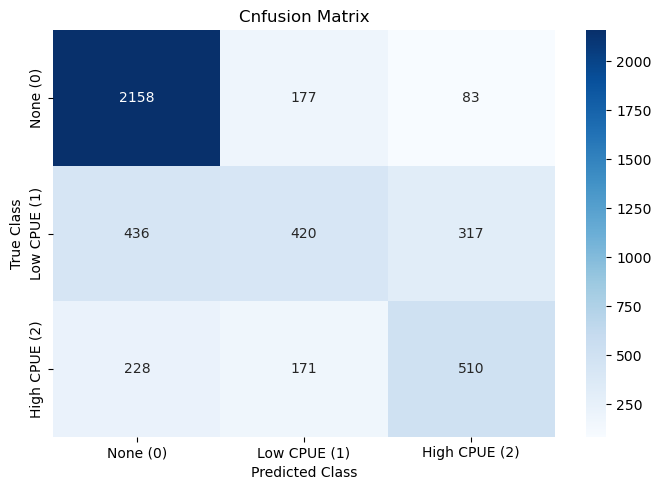

In [ ]:
model = RandomForestClassifier(n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=42)

model.fit(X_train_ml, y_train_ml)

y_pred_flat = model.predict(X_test_ml)

report, iou_per_class, kappa, cm, y_true_plot, y_pred_plot, r2_plot = compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)

# -------- Feature Importance Extraction --------
raw_importances = model.feature_importances_
T = X_train.shape[1]   # window (12)
C = X_train.shape[2]   # number of variables/channels
H_x = X_train.shape[3] # height (lat)
W_x = X_train.shape[4] # width (lon)

reshaped_importances = raw_importances.reshape(T, C, H_x, W_x)

variable_importances = reshaped_importances.sum(axis=(0, 2, 3))


importance_df = pd.DataFrame({
    'Variable': vars_names,
    'Importance': variable_importances
})

# Sort in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
print(importance_df)


# get the summary statistics and save
model_name = model.__class__.__name__
iou_per_class = pd.DataFrame(iou_per_class, index=["Clase 0", "Clase 1", "Clase 2"], columns=["IoU"])

metrics_df = pd.DataFrame({
    "Cohen's Kappa": [kappa],
    "Agg R2": [r2_plot],
})


plt.figure(figsize=(10, 3))
plt.plot(y_true_plot, label="Verdadero", marker='o', markersize=3)
plt.plot(y_pred_plot, color="Predicho", label="Predicted")
plt.annotate(f"R2: {r2_plot:.3f}", xy=(0.98, 0.02), xycoords='axes fraction', ha='right', va='bottom')
plt.xlabel("Tiempo (Meses)")
plt.ylabel("Clases agregadas")
plt.title(f"Serie temporal de {model_name}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
img_buffer2 = BytesIO()
plt.savefig(img_buffer2, format="png", bbox_inches="tight")
img_buffer2.seek(0)
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d')
plt.xlabel("Clase predicha")
plt.ylabel("Clase verdadera")
plt.title("Cnfusion Matrix")
plt.tight_layout()
img_buffer3 = BytesIO()
plt.savefig(img_buffer3, format="png", bbox_inches="tight")
img_buffer3.seek(0)
plt.show()

# save everyhtng to a excel workbook

sheet_name = f"{model_name}_{sp}"
with pd.ExcelWriter("./modelos/resultados/Class/ML_cla.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    report.to_excel(writer, sheet_name=sheet_name, startrow=1)

with pd.ExcelWriter("./modelos/resultados/Class/ML_cla.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    iou_per_class.to_excel(writer, sheet_name=sheet_name, startrow=len(report) + 3)
    metrics_df.to_excel(writer, sheet_name=sheet_name, startrow=len(report) + len(iou_per_class) + 6, index=False)
    ws = writer.sheets[sheet_name]
    img2 = Image(img_buffer2)
    ws.add_image(img2, f"N1")
    img3 = Image(img_buffer3)
    ws.add_image(img3, f"N21")


=== Classification Report ===
              precision    recall  f1-score      support
0              0.772120  0.884202  0.824369  2418.000000
1              0.516364  0.363171  0.426426  1173.000000
2              0.543046  0.541254  0.542149   909.000000
accuracy       0.679111  0.679111  0.679111     0.679111
macro avg      0.610510  0.596209  0.597648  4500.000000
weighted avg   0.659180  0.679111  0.663630  4500.000000
=== Spatial Segmentation Metrics ===
IoU Class 1 (Low CPUE):      0.271
IoU Class 2 (High CPUE):     0.372
Cohen's Kappa Score:         0.448

Mean Masked SSIM: 0.4441



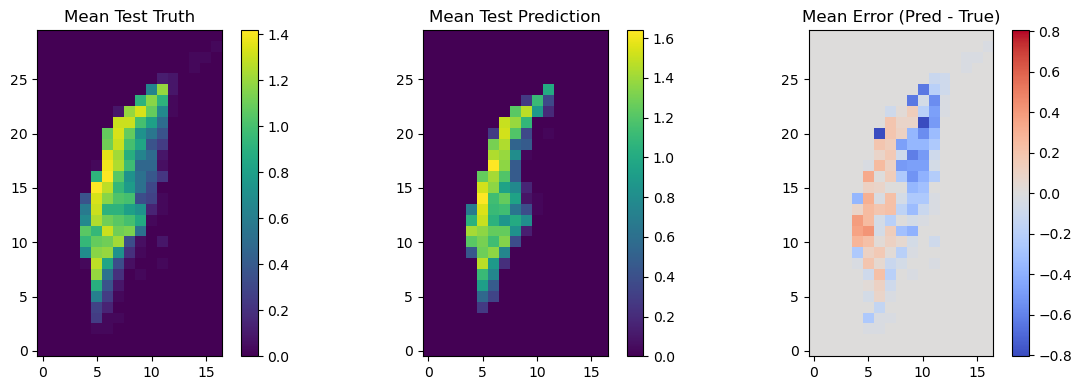

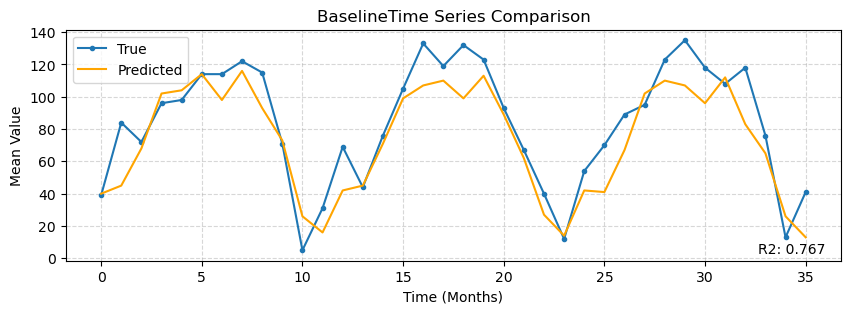

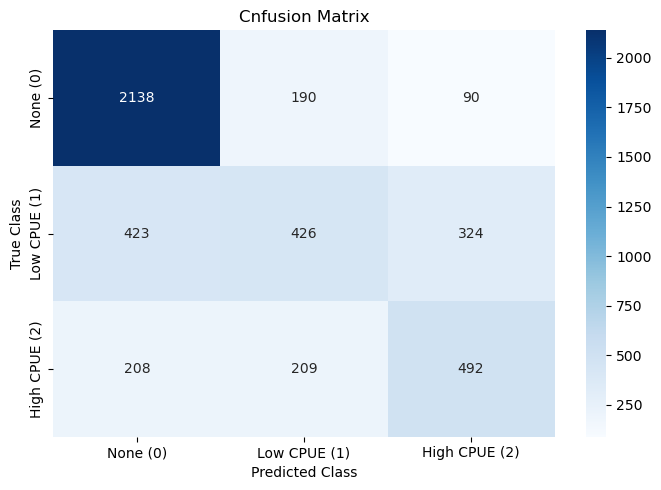

In [ ]:
model = ExtraTreesClassifier(n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=42)

model.fit(X_train_ml, y_train_ml)
y_pred_flat = model.predict(X_test_ml)

report, iou_per_class, kappa, cm, y_true_plot, y_pred_plot, r2_plot = compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)

# get the summary statistics and save
model_name = model.__class__.__name__
iou_per_class = pd.DataFrame(iou_per_class, index=["Clase 0", "Clase 1", "Clase 2"], columns=["IoU"])

metrics_df = pd.DataFrame({
    "Cohen's Kappa": [kappa],
    "Agg R2": [r2_plot],
})


plt.figure(figsize=(10, 3))
plt.plot(y_true_plot, label="Verdadero", marker='o', markersize=3)
plt.plot(y_pred_plot, color="Predicho", label="Predicted")
plt.annotate(f"R2: {r2_plot:.3f}", xy=(0.98, 0.02), xycoords='axes fraction', ha='right', va='bottom')
plt.xlabel("Tiempo (Meses)")
plt.ylabel("Clases agregadas")
plt.title(f"Serie temporal de {model_name}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
img_buffer2 = BytesIO()
plt.savefig(img_buffer2, format="png", bbox_inches="tight")
img_buffer2.seek(0)
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d')
plt.xlabel("Clase predicha")
plt.ylabel("Clase verdadera")
plt.title("Cnfusion Matrix")
plt.tight_layout()
img_buffer3 = BytesIO()
plt.savefig(img_buffer3, format="png", bbox_inches="tight")
img_buffer3.seek(0)
plt.show()

# save everyhtng to a excel workbook

sheet_name = f"{model_name}_{sp}"
with pd.ExcelWriter("./modelos/resultados/Class/ML_cla.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    report.to_excel(writer, sheet_name=sheet_name, startrow=1)

with pd.ExcelWriter("./modelos/resultados/Class/ML_cla.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    iou_per_class.to_excel(writer, sheet_name=sheet_name, startrow=len(report) + 3)
    metrics_df.to_excel(writer, sheet_name=sheet_name, startrow=len(report) + len(iou_per_class) + 6, index=False)
    ws = writer.sheets[sheet_name]
    img2 = Image(img_buffer2)
    ws.add_image(img2, f"N1")
    img3 = Image(img_buffer3)
    ws.add_image(img3, f"N21")
